In [2]:
import os
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from lightgbm import LGBMClassifier

In [11]:
BASE_DIR = os.getcwd()

DATA_PATH = os.path.join(
    BASE_DIR,
    "app",
    "data",
    "FINAL_Balanced_Behavioral_Loan_Risk_Dataset(I).csv"
)

MODEL_DIR = os.path.join(BASE_DIR, "app", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

In [12]:
df = pd.read_csv(DATA_PATH)
print("Original shape:", df.shape)


Original shape: (3381, 18)


In [13]:
df = df.dropna(subset=["Loan_Status"])

df["Loan_Status"] = df["Loan_Status"].str.strip().str.lower()

df["Was_Defaulted"] = (df["Loan_Status"] == "defaulted").astype(int)

df["Loan_Status"] = df["Loan_Status"].map({
    "approved": 1,
    "rejected": 0,
    "defaulted": 0
})

df = df.dropna(subset=["Loan_Status"])
df["Loan_Status"] = df["Loan_Status"].astype(int)

print("Target distribution:\n", df["Loan_Status"].value_counts())

Target distribution:
 Loan_Status
1    1727
0    1654
Name: count, dtype: int64


In [14]:
X = df.drop(columns=["Customer_ID", "Loan_Status"], errors="ignore")
y = df["Loan_Status"]


In [15]:
X["Income_Loan_Ratio"] = X["Monthly_Income"] / (X["Loan_Amount"] + 1)

X["Behavior_Risk_Mean"] = (
    X["Payment_Irregularity"] +
    X["Behavioral_Anomaly_Index"] +
    X["Transaction_Inconsistency"]
) / 3

X["Transaction_Intensity"] = (
    X["Avg_Transaction_Freq"] * X["Avg_Transaction_Amount"]
)

X["Risk_to_Income"] = X["Default_Risk_Score"] / (X["Monthly_Income"] + 1)

In [16]:
categorical_cols = ["Gender", "Age_Group", "Region", "Loan_Purpose"]

for col in categorical_cols:
    if col in X.columns:
        X[col] = X[col].astype("category").cat.codes

In [17]:
X = X.select_dtypes(include=["int64", "float64"])

In [18]:
X = X.fillna(X.median())

In [19]:
y = y.loc[X.index]

print("NaNs in X:", X.isna().sum().sum())
print("NaNs in y:", y.isna().sum())

NaNs in X: 0
NaNs in y: 0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
model = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.85,
    class_weight="balanced",
    random_state=42
)

In [22]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc"
)

[LightGBM] [Info] Number of positive: 1381, number of negative: 1323
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000396 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2874
[LightGBM] [Info] Number of data points in the train set: 2704, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.03
,n_estimators,600
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [23]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6573116691285081
ROC AUC: 0.715287358329113

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.73      0.68       331
           1       0.70      0.59      0.64       346

    accuracy                           0.66       677
   macro avg       0.66      0.66      0.66       677
weighted avg       0.66      0.66      0.66       677



In [24]:
# Save SHAP background data (VERY IMPORTANT)
background = X.sample(100, random_state=42)

joblib.dump(
    background,
    os.path.join(MODEL_DIR, "shap_background.pkl")
)


['d:\\project\\Ai Agent\\backend\\app\\models\\shap_background.pkl']

In [25]:
joblib.dump(model, os.path.join(MODEL_DIR, "loan_model.pkl"))
joblib.dump(list(X.columns), os.path.join(MODEL_DIR, "feature_names.pkl"))

print("\n✅ OPTIMIZED MODEL TRAINING COMPLETE")
print("Model saved in:", MODEL_DIR)


✅ OPTIMIZED MODEL TRAINING COMPLETE
Model saved in: d:\project\Ai Agent\backend\app\models


In [26]:
import shap

d:\project\Ai Agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
explainer = shap.TreeExplainer(model)
background = X_train.sample(100, random_state=42)
explainer = shap.TreeExplainer(model, data=background)

In [19]:
shap_values = explainer.shap_values(X_test, check_additivity=False)

if isinstance(shap_values, list):
    shap_values = shap_values[1]



 94%|=================== | 636/677 [00:12<00:00]       

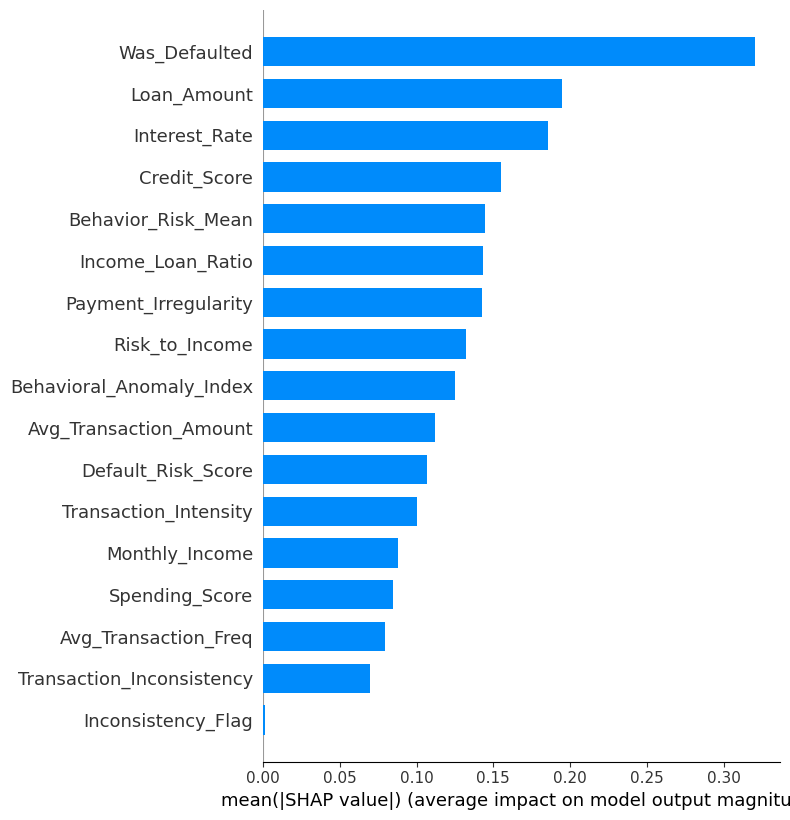

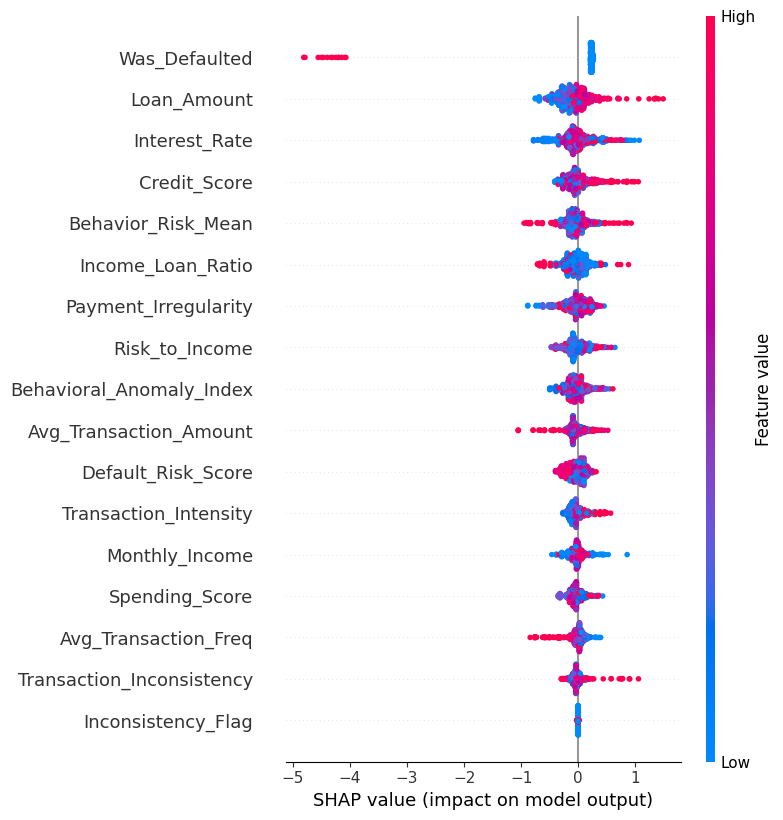

In [20]:
shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)

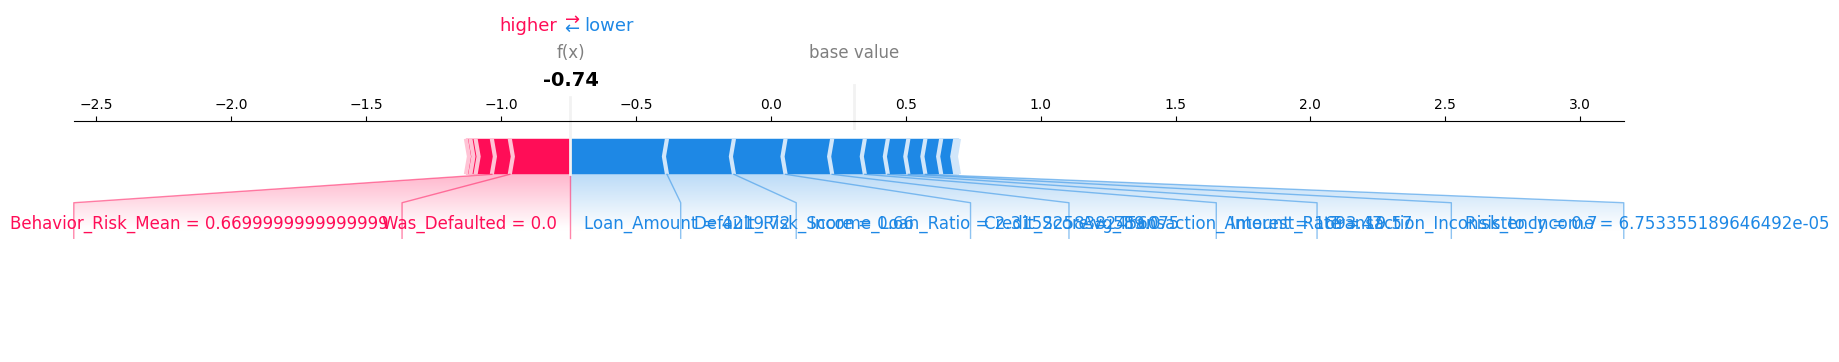

In [22]:
idx = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)

In [3]:
MODEL_PATH = "app/models/loan_model.pkl"
FEATURES_PATH = "app/models/feature_names.pkl"

model = joblib.load(MODEL_PATH)
feature_names = joblib.load(FEATURES_PATH)

print("Model and features loaded.")

Model and features loaded.


In [4]:
def preprocess_input_notebook(data: dict):
    df = pd.DataFrame([data])

    # Feature engineering (same as training)
    df["Income_Loan_Ratio"] = df["Monthly_Income"] / (df["Loan_Amount"] + 1)

    df["Behavior_Risk_Mean"] = (
        df["Payment_Irregularity"]
        + df["Behavioral_Anomaly_Index"]
        + df["Transaction_Inconsistency"]
    ) / 3

    df["Transaction_Intensity"] = (
        df["Avg_Transaction_Freq"] * df["Avg_Transaction_Amount"]
    )

    df["Risk_to_Income"] = df["Default_Risk_Score"] / (df["Monthly_Income"] + 1)

    # Encode categoricals (same logic)
    categorical_cols = ["Gender", "Age_Group", "Region", "Loan_Purpose"]
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype("category").cat.codes

    # Align features
    df = df.reindex(columns=feature_names, fill_value=0)

    return df


In [6]:
approve_case = {
    "Gender": "Male",
    "Age_Group": "26-35",
    "Region": "Urban",
    "Loan_Purpose": "Education",
    "Monthly_Income": 60000,
    "Loan_Amount": 250000,
    "Interest_Rate": 10.5,
    "Avg_Transaction_Freq": 50,
    "Avg_Transaction_Amount": 1600,
    "Payment_Irregularity": 0.1,
    "Behavioral_Anomaly_Index": 0.1,
    "Transaction_Inconsistency": 0.1,
    "Default_Risk_Score": 0.2
}


In [7]:
reject_case = {
    "Gender": "Male",
    "Age_Group": "18-25",
    "Region": "Rural",
    "Loan_Purpose": "Personal",
    "Monthly_Income": 25000,
    "Loan_Amount": 400000,
    "Interest_Rate": 15.0,
    "Avg_Transaction_Freq": 15,
    "Avg_Transaction_Amount": 700,
    "Payment_Irregularity": 0.6,
    "Behavioral_Anomaly_Index": 0.5,
    "Transaction_Inconsistency": 0.5,
    "Default_Risk_Score": 0.55
}


In [9]:
def test_case(label, data):
    X = preprocess_input_notebook(data)
    prob = model.predict_proba(X)[0][1]
    decision = "Approved" if prob >= 0.6 else "Rejected"

    print(f"\n--- {label} ---")
    print("Approval Probability:", round(prob, 3))
    print("Decision:", decision)

# Run tests
test_case("EXPECTED APPROVAL", approve_case)
test_case("EXPECTED REJECTION", reject_case)



--- EXPECTED APPROVAL ---
Approval Probability: 0.939
Decision: Approved

--- EXPECTED REJECTION ---
Approval Probability: 0.961
Decision: Approved


In [27]:
# Check class distribution
print(y.value_counts(normalize=True))


Loan_Status
1    0.510796
0    0.489204
Name: proportion, dtype: float64
